In [2]:
import time
import jax
import jax.numpy as jnp
from jaxtyping import Float64, Array, jaxtyped
import matplotlib.pyplot as plt
from beartype import beartype

from KiRATE.species import Species, fit_smooth_nasa7_coefficients

Time for fitting species: 0.04744491702876985
 Time for refitting a mech: 23.722458514384925


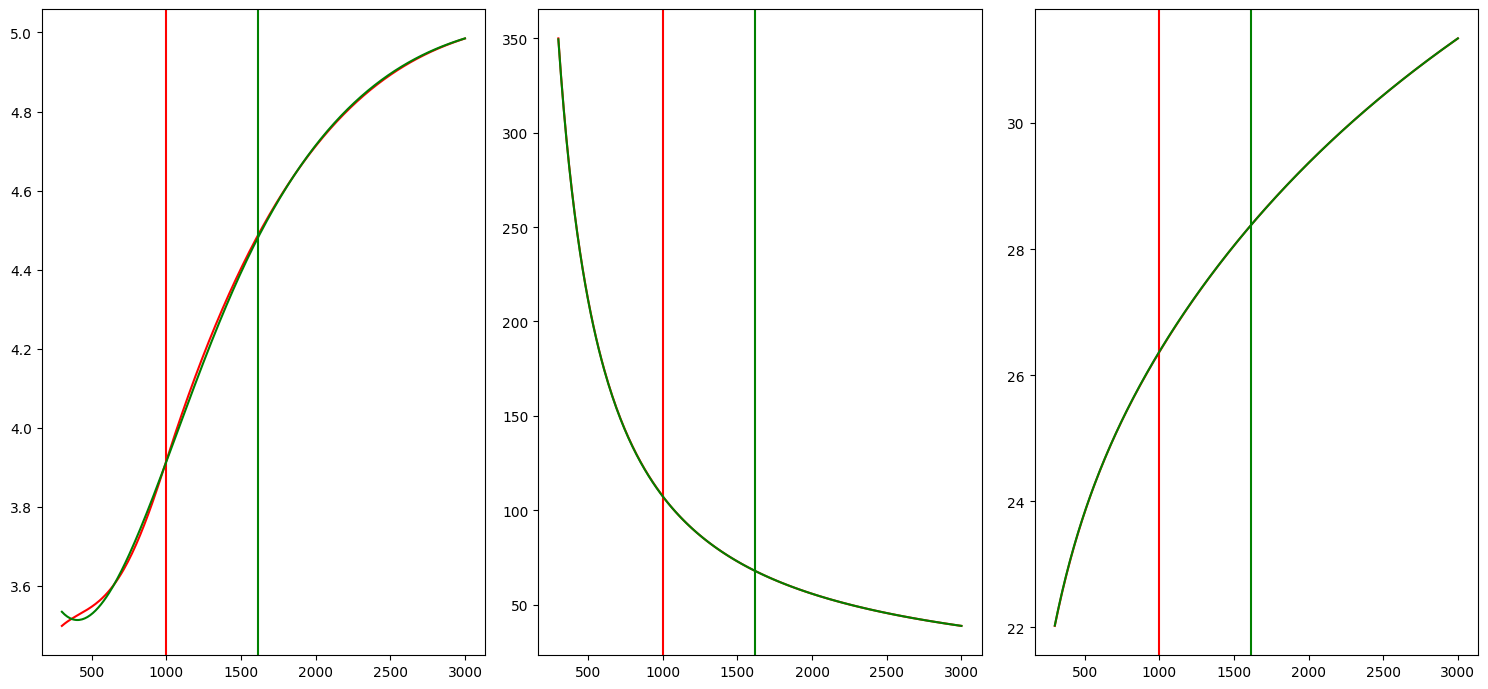

In [9]:
spec = Species.from_chemkin(
    """
    CH*               073003C   1H   1          G  0300.00   5000.00  1000.00      1
     0.02196223E+02 0.02340381E-01-0.07058201E-05 0.09007582E-09-0.03855040E-13    2
     0.10419559E+06 0.09178373E+02 0.03200202E+02 0.02072875E-01-0.05134431E-04    3
     0.05733890E-07-0.01955533E-10 0.10393714E+06 0.03331587E+02                   4
    """
)


start = time.perf_counter()
new_spec = fit_smooth_nasa7_coefficients(spec)
end = time.perf_counter()

print(f"Time for fitting species: {end - start}")
print(f" Time for refitting a mech: {(end - start)*500}")

T = jnp.linspace(300, 3000, 300)

cp_r_og = spec.cp_over_r(T)
cp_r_new = new_spec.cp_over_r(T)

h_rt_og = spec.h_over_rt(T)
h_rt_new = new_spec.h_over_rt(T)

s_r_og = spec.s_over_r(T)
s_r_new = new_spec.s_over_r(T)


fig, ax = plt.subplots(1, 3, figsize=(15, 7))

ax[0].plot(T, cp_r_og, "r")
ax[0].axvline(x=spec.Tmid, color="r")
ax[0].plot(T, cp_r_new, "g")
ax[0].axvline(x=new_spec.Tmid, color="g")

ax[1].plot(T, h_rt_og, "r")
ax[1].axvline(x=spec.Tmid, color="r")
ax[1].plot(T, h_rt_new, "g")
ax[1].axvline(x=new_spec.Tmid, color="g")

ax[2].plot(T, s_r_og, "r")
ax[2].axvline(x=spec.Tmid, color="r")
ax[2].plot(T, s_r_new, "g")
ax[2].axvline(x=new_spec.Tmid, color="g")

fig.tight_layout()
plt.show()